# 从海豚原始图像识别并剪裁背鳍

使用训练后的 Yolo 模型，需指定 JPG 文件夹.
结束后背鳍存在子文件夹 FIN 中，生成元数据 csv.

When the same fin are detected multiple times, try to increase the confidence or filter with IoU.
https://github.com/ultralytics/ultralytics/issues/5811

In [2]:
import os
import glob
import cv2
from tqdm import tqdm
import pandas as pd
from PIL import Image
from ultralytics import YOLO
from matplotlib import pyplot as plt

In [4]:
# Initlize YOLO with best model file
fin_detector = YOLO("models/fin_yolo_best.pt")

In [5]:
# The path contains camera jpeg files
dataset_path = r'/media/filming/2025-白海豚/20240824_JM_01_v2/'
JPG_paths = glob.glob(os.path.join(dataset_path, '*.JPG'))
JPG_paths.sort() # Sort in human readable

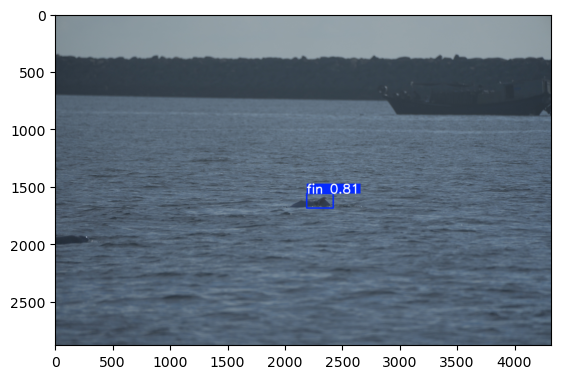

In [14]:
# Test one of image
test_img = JPG_paths[20]
result = fin_detector(test_img)
annoted_image = result[0].plot()
annoted_image = Image.fromarray(annoted_image[..., ::-1])  # RGB-order PIL image
plt.imshow(annoted_image)

In [10]:
result[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.], device='cuda:0')
conf: tensor([0.3215], device='cuda:0')
data: tensor([[1.8471e+03, 1.2470e+03, 2.0987e+03, 1.4063e+03, 3.2151e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (2880, 4320)
shape: torch.Size([1, 6])
xywh: tensor([[1972.9121, 1326.6704,  251.5883,  159.3007]], device='cuda:0')
xywhn: tensor([[0.4567, 0.4606, 0.0582, 0.0553]], device='cuda:0')
xyxy: tensor([[1847.1180, 1247.0200, 2098.7063, 1406.3207]], device='cuda:0')
xyxyn: tensor([[0.4276, 0.4330, 0.4858, 0.4883]], device='cuda:0')

In [29]:
from check_duplicate_detections import filter_duplicate_detections

In [41]:
# Extract and Crop Fin from Orignal Image, One by One
meta_info = pd.DataFrame(columns=["identify", "path", "crop_conf", 
                                  "x_min", "x_max", "y_min", "y_max", 
                                  "orig_img", "orig_img_h", ""])
IOU_THRESHOLD = 0.6 
for JPG_path  in tqdm(JPG_paths):
    ori_img_name = os.path.basename(JPG_path)
    results = fin_detector(JPG_path, verbose=False)
    for result in results:
        boxes = result.boxes        
        if boxes is None or len(boxes) == 0 :
            continue
        # Remove duplicated fin which are detected multiple times
        keep_indices = filter_duplicate_detections(boxes, IOU_THRESHOLD)
        for new_idx, fin_idx in enumerate(keep_indices):
            xyxy = boxes[fin_idx].xyxy
            x0, y0, x1, y1 = [int(i) for i in xyxy[0]]
            conf = float(boxes[fin_idx].conf)
            cropped_img = result.orig_img[y0:y1, x0:x1, :]
            save_dir = dataset_path + "/FIN/"
            os.makedirs(save_dir, exist_ok=True)
            img_name = ori_img_name[:-4] + "_FIN%02d.JPG"%new_idx
            fin_img_path =  "FIN/" + img_name 
            cv2.imwrite(save_dir + img_name, cropped_img)

            orig_img_h, orig_img_w = result[0].boxes.orig_shape
            new_row = {"path": fin_img_path, "crop_conf": conf, 
                       "x_min": x0, "x_max": x1, "y_min": y0, "y_max": y1,
                      "orig_img": ori_img_name, "orig_img_h": orig_img_h, "orig_img_w": orig_img_w}
            meta_info.loc[len(meta_info)] = new_row
meta_info.identify = range(len(meta_info))

Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicated fin 1
Remove duplicate

In [42]:
meta_info.to_csv(dataset_path + "FIN_METAINFO.csv")

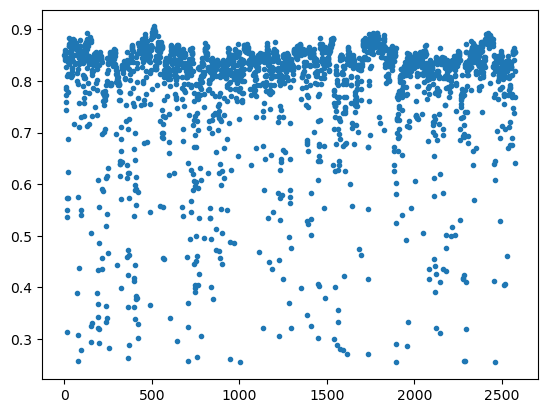

In [43]:
plt.plot(meta_info.crop_conf, ".")

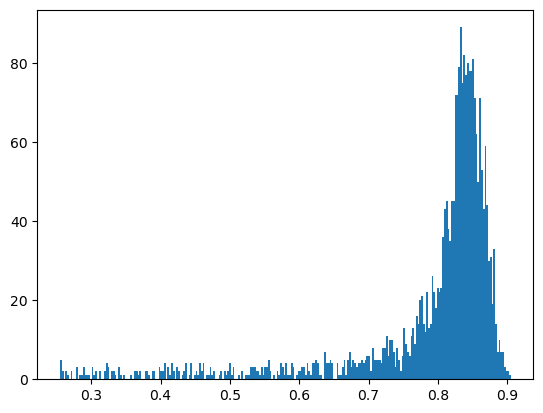

In [44]:
plt.hist(meta_info.crop_conf, bins=256)
plt.show()